# Image Recognition

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [3]:

mnist = tf.keras.datasets.mnist

In [4]:

(x_train, y_train),(x_test, y_test) = mnist.load_data() #way to load mnist dataset using mnist.load_data() function
x_train = tf.keras.utils.normalize(x_train, axis = 1)
x_test = tf.keras.utils.normalize(x_test, axis = 1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [5]:
# -1 is a shorthand, which returns the length of the dataset
#(batch_size, height, width, channels)
x_trainr = np.array(x_train).reshape(-1, 28, 28, 1)
x_testr = np.array(x_test).reshape(-1, 28, 28, 1)

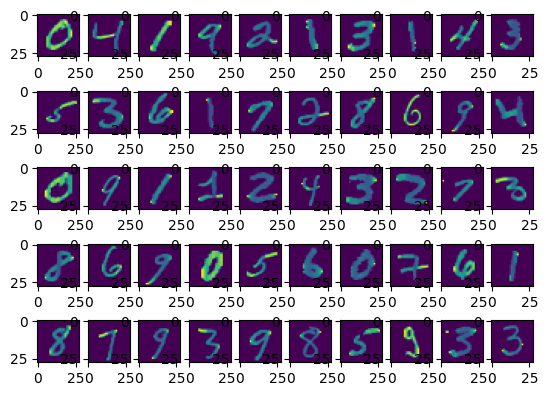

In [6]:
for i in range(1,51): #plots a grid of 50 images with
  plt.subplot(5,10,i) #10 images per row and total 5 rows
  plt.imshow(x_train[i]) #plt.imshow() is then used to display the image corresponding to the 'i' index of the 'x_train' dataset
     



In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
     

In [10]:
#Creating a new sequential model

In [11]:

model = Sequential()

In [12]:
### First Convolution Layer
# 64 -> number of filters, (3,3) -> size of each kernal,
model.add(Conv2D(64, (3,3), input_shape = x_trainr.shape[1:])) # For first layer we have to mention the size of input
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
### Second Convolution Layer
model.add(Conv2D(64, (3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
### Third Convolution Layer
model.add(Conv2D(64, (3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
### Fully connected layer 1
model.add(Flatten())
model.add(Dense(64))
model.add(Activation("relu"))
### Fully connected layer 2
model.add(Dense(32))
model.add(Activation("relu"))
### Fully connected layer 3, output layer must be equal to number of classes
model.add(Dense(10))
model.add(Activation("softmax"))

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary() #displays a compact overview of the model
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=['accuracy']) #used to configure the model for training
     

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 26, 26, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 11, 11, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 3, 3, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 3, 3, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 1, 1, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             330 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_5 (Activation)            │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 81,066 (316.66 KB)

 Trainable params: 81,066 (316.66 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.fit(x_trainr, y_train, epochs=5, validation_split = 0.3)

Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 25ms/step - accuracy: 0.8945 - loss: 0.3316 - val_accuracy: 0.9610 - val_loss: 0.1250
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 23ms/step - accuracy: 0.9693 - loss: 0.1010 - val_accuracy: 0.9738 - val_loss: 0.0925
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.9778 - loss: 0.0713 - val_accuracy: 0.9749 - val_loss: 0.0818
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 22ms/step - accuracy: 0.9812 - loss: 0.0584 - val_accuracy: 0.9760 - val_loss: 0.0800
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 22ms/step - accuracy: 0.9856 - loss: 0.0454 - val_accuracy: 0.9767 - val_loss: 0.0787


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9788 - loss: 0.0742
Test Loss on 10,000 test samples 0.07424909621477127
Test Accuracy on 10,000 test samples 0.9787999987602234
 11/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=('Tensor(shape=(32, 28, 28, 1))',)
  warnings.warn(msg)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=('Tensor(shape=(None, 28, 28, 1))',)
  warnings.warn(msg)


[2.6984193e-07 3.9828334e-05 6.7912252e-04 2.4301055e-05 1.8431444e-07
 1.5009731e-07 1.0957271e-09 9.9922562e-01 7.4836712e-06 2.3038738e-05]
7


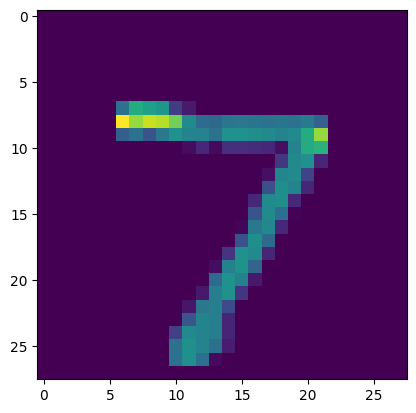

In [15]:
test_loss, test_acc = model.evaluate(x_testr, y_test)
print("Test Loss on 10,000 test samples", test_loss)
print("Test Accuracy on 10,000 test samples", test_acc)
predictions = model.predict([x_testr])
#print(predictions)
plt.imshow(x_test[0])
print(predictions[0])
print(np.argmax(predictions[0]))

In [18]:
import cv2
img2 = cv2.imread("image.jpg")



In [19]:
img2 = cv2.imread("image.jpg")

if img2 is None:
    print("Image not loaded. Check file path.")


Image not loaded. Check file path.


TypeError: Image data of dtype object cannot be converted to float

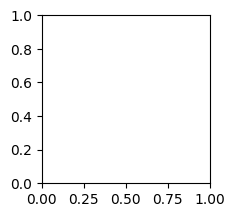

In [21]:
import cv2
img2 = cv2.imread('/img2.jpg')
#binary image
ret, img1 = cv2.threshold(img2, 75, 255, cv2.THRESH_BINARY)
# invert binary image
img = cv2.bitwise_not(img1)
plt.subplot(221)
plt.imshow(img2)
plt.subplot(222)
plt.imshow(img1)
plt.subplot(223)
plt.imshow(img)
# Converting to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray.shape
# Resizing to a 28x28 image
resized = cv2.resize(gray, (28,28), interpolation = cv2.INTER_AREA)
resized.shape
#ret, bw_img = cv2.threshold(resized, 80, 255, cv2.THRESH_BINARY)
plt.subplot(224)
plt.imshow(resized)


In [24]:
img = cv2.imread("image.png", cv2.IMREAD_GRAYSCALE)
